# Mix energetico in Europa: nucleare, rinnovabili e fossili

Analisi dell’evoluzione delle fonti di produzione elettrica nei paesi europei, con focus sul confronto tra nucleare, rinnovabili e combustibili fossili nel periodo 1990–2025.

## 1. Fonte dei dati

I dati provengono dall’**Energy Dataset** di [Our World in Data](https://github.com/owid/energy-data), che aggrega e armonizza rilevazioni da fonti istituzionali internazionali — principalmente **Ember** (*Yearly Electricity Data*, copertura sistematica dal 1990 per i paesi europei) e **Energy Institute** (*Statistical Review of World Energy*, serie storiche precedenti). Il dataset è aggiornato al 2026 e rilasciato sotto licenza **CC BY**.

> Ember (2026); Energy Institute - Statistical Review of World Energy (2025) — with major processing by Our World in Data.

In [48]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd()
df = pd.read_csv(DATA_DIR / "data" / "owid-energy-data.csv")

print(df.shape)
df.head()

(23377, 130)


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [49]:
codebook = pd.read_csv(DATA_DIR / "data" / "owid-energy-codebook.csv")

print(codebook.shape)
codebook.head()

(130, 5)


,column,title,description,unit,source
0,country,Country,Geographic location.,NaN,Our World in Data - Regions (2025)
1,year,Year,Year of observation.,NaN,Our World in Data - Regions (2025)
2,iso_code,ISO code,ISO 3166-1 alpha-3 three-letter country codes.,NaN,International Organization for Standardization...
3,population,Population,"Population by country, available from 10,000 B...",people,Population based on various sources (2024) [ht...
4,gdp,Gross domestic product (GDP),Total economic output of a country or region p...,international-$ in 2011 prices ($),Bolt and van Zanden – Maddison Project Databas...


## 2. Struttura del dataset

Il dataset è in formato **long**: una riga per combinazione di paese e anno, 130 variabili energetiche. Include sia paesi reali che aggregati geografici ed economici costruiti da OWID.

In [50]:
print(f"Righe: {df.shape[0]:,}")
print(f"Colonne: {df.shape[1]}")
print(f"Periodo: {df['year'].min()} - {df['year'].max()}")
print(f"Entità (paesi + aggregati): {df['country'].nunique()}")


Righe: 23,377
Colonne: 130
Periodo: 1900 - 2025
Entità (paesi + aggregati): 314


La colonna `country` contiene anche **aggregati** (continenti, “World”, “EU (Ember)”, “G7 (Ember)” ecc.), riconoscibili dall’assenza di `iso_code`. L’analisi successiva lavora esclusivamente su paesi con codice ISO valido.

In [51]:
# Quante "entità" non sono paesi veri (non hanno iso_code)?
aggregati = sorted(df.loc[df["iso_code"].isna(), "country"].unique())
print(f"Aggregati/non-paesi individuati: {len(aggregati)}")
aggregati[:15]  # primi esempi


Aggregati/non-paesi individuati: 94


['ASEAN (Ember)',
 'Africa',
 'Africa (EI)',
 'Africa (EIA)',
 'Africa (Ember)',
 'Africa (Shift)',
 'Asia',
 'Asia (Ember)',
 'Asia Pacific (EI)',
 'Asia and Oceania (EIA)',
 'Asia and Oceania (Shift)',
 'Australia and New Zealand (EIA)',
 'CIS (EI)',
 'Central America (EI)',
 'Central and South America (EIA)']

## 3. Analisi dei valori mancanti

Il dataset presenta un numero rilevante di `NaN`. Prima di qualsiasi analisi è necessario stabilire se siano **casuali** o **strutturali** — ovvero se la loro distribuzione segua una logica spiegabile da fattori osservabili.

Ogni variabile viene classificata per ciascun paese in quattro pattern: `complete`, `left-censored` (NaN solo prima dell’anno di primo rilevamento), `internal-gaps` (lacune interne alla serie) e `always-null` (nessun dato disponibile). L’analisi è condotta separatamente per l’Europa e per il resto del mondo.

In [52]:
EUROPE_ISO = {
    "ALB", "AND", "AUT", "BLR", "BEL", "BIH", "BGR", "HRV", "CYP", "CZE",
    "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN", "ISL", "IRL", "ITA",
    "XKX", "LVA", "LIE", "LTU", "LUX", "MLT", "MDA", "MCO", "MNE", "NLD",
    "MKD", "NOR", "POL", "PRT", "ROU", "RUS", "SMR", "SRB", "SVK", "SVN",
    "ESP", "SWE", "CHE", "UKR", "GBR", "VAT",
}

KEY_COLS = [
    "electricity_generation",
    "fossil_electricity",
    "nuclear_electricity",
    "renewables_electricity",
    "solar_electricity",
    "wind_electricity",
    "hydro_electricity",
]

df_eu = df[df["iso_code"].isin(EUROPE_ISO)].copy()
print(f"Paesi europei nel dataset: {df_eu['country'].nunique()}")
print(f"Righe totali: {len(df_eu):,}  |  Anni: {df_eu['year'].min()}–{df_eu['year'].max()}")

Paesi europei nel dataset: 40
Righe totali: 3,488  |  Anni: 1900–2025


In [53]:
def classify_missing(series: pd.Series) -> dict:
    first_idx = series.first_valid_index()
    if first_idx is None:
        return {"first_valid": None, "nan_before": int(series.isna().sum()), "nan_after": 0, "pattern": "always-null"}
    nan_before = int(series.loc[:first_idx].iloc[:-1].isna().sum())
    nan_after  = int(series.loc[first_idx:].isna().sum())
    if nan_after == 0:
        pattern = "complete" if nan_before == 0 else "left-censored"
    else:
        pattern = "internal-gaps"
    return {"first_valid": first_idx, "nan_before": nan_before, "nan_after": nan_after, "pattern": pattern}


def gap_ranges(s: pd.Series, first_idx) -> str | None:
    """Restituisce gli anni NaN dopo first_idx come stringa di intervalli, o None se assenti."""
    gap_years = s.loc[first_idx:][s.loc[first_idx:].isna()].index.tolist()
    if not gap_years:
        return None
    ranges, start, prev = [], gap_years[0], gap_years[0]
    for y in gap_years[1:]:
        if y == prev + 1:
            prev = y
        else:
            ranges.append(f"{start}–{prev}" if start != prev else str(start))
            start = prev = y
    ranges.append(f"{start}–{prev}" if start != prev else str(start))
    return ", ".join(ranges)


def build_miss(df_subset: pd.DataFrame) -> pd.DataFrame:
    """Classifica il pattern dei missing values per ogni coppia paese × colonna chiave."""
    records = []
    for country, grp in df_subset.groupby("country"):
        grp_sorted = grp.sort_values("year").set_index("year")
        for col in KEY_COLS:
            if col in grp_sorted.columns:
                records.append({"country": country, "column": col, **classify_missing(grp_sorted[col])})
    return pd.DataFrame(records)


miss = build_miss(df_eu)

### 3.1 Copertura temporale dei paesi europei

In [54]:
print("=== Distribuzione dei pattern — Europa (paese × colonna) ===")
print(miss["pattern"].value_counts().to_string())

print("\n=== Anno del primo dato valido ===")
pivot = miss[miss["pattern"] != "always-null"].pivot(
    index="country", columns="column", values="first_valid"
).astype("Int64")
print(pivot.to_string())

print("\n=== Gap interni ===")
for country, grp in df_eu.groupby("country"):
    grp_sorted = grp.sort_values("year").set_index("year")
    for col in KEY_COLS:
        if col not in grp_sorted.columns:
            continue
        s = grp_sorted[col]
        first_idx = s.first_valid_index()
        if first_idx is None:
            continue
        r = gap_ranges(s, first_idx)
        if r:
            print(f"  {country:30s}  {col:30s}  {r}")

=== Distribuzione dei pattern — Europa (paese × colonna) ===
pattern
left-censored    174
complete          86
internal-gaps     20

=== Anno del primo dato valido ===
column                  electricity_generation  fossil_electricity  hydro_electricity  nuclear_electricity  renewables_electricity  solar_electricity  wind_electricity
country                                                                                                                                                                
Albania                                   2000                2000               2000                 2000                    2000               2000              2000
Austria                                   1985                1990               1965                 1965                    1965               1965              1965
Belarus                                   1985                2000               1985                 1985                    1985               1985           

**Europa — copertura**

Il left-censoring è il pattern dominante (174 coppie paese-colonna), ma il 1990 non è il punto di partenza tipico: il 71% di queste serie inizia *prima* del 1990, con mediana al 1965. La soglia del 1990 vale soprattutto per `fossil_electricity`, dove la maggior parte dei paesi parte effettivamente da quell'anno. Per le altre sei variabili chiave (generazione totale, nucleare, rinnovabili, solare, eolico, idroelettrico), 25 dei 40 paesi europei hanno dati già dal 1965 grazie alle serie storiche dell'Energy Institute — non un'eccezione limitata a poche grandi economie, ma la norma per la maggior parte dell'Europa occidentale e settentrionale. Il 1990 riguarda soprattutto gli ex paesi sovietici e jugoslavi (dati dal 1985 o 1990) e i paesi entrati più tardi nella rilevazione (Albania, Bosnia, Moldova dal 2000; Montenegro dal 2005).

I gap interni si concentrano sui paesi successori dell'URSS e della Jugoslavia — con discontinuità tipicamente tra il 1990 e il 1993. I microstati (Andorra, Monaco, Liechtenstein, San Marino, Vaticano) registrano always-null su variabili come `nuclear_electricity`, fisicamente assente dal loro territorio.

### 3.2 Copertura nel resto del mondo

In [55]:
df_world = df[df["iso_code"].notna() & ~df["iso_code"].isin(EUROPE_ISO)].copy()
print(f"Paesi non europei nel dataset: {df_world['country'].nunique()}")

miss_w = build_miss(df_world)

print("\n=== Distribuzione dei pattern — Resto del mondo (paese × colonna) ===")
print(miss_w["pattern"].value_counts().to_string())

print("\n=== Anno del primo dato valido ===")
pivot_w = miss_w[miss_w["pattern"] != "always-null"].pivot(
    index="country", columns="column", values="first_valid"
).astype("Int64")
print(pivot_w.to_string())

print("\n=== Gap interni ===")
found_any = False
for country, grp in df_world.groupby("country"):
    grp_sorted = grp.sort_values("year").set_index("year")
    for col in KEY_COLS:
        if col not in grp_sorted.columns:
            continue
        s = grp_sorted[col]
        first_idx = s.first_valid_index()
        if first_idx is None:
            continue
        r = gap_ranges(s, first_idx)
        if r:
            found_any = True
            print(f"  {country:40s}  {col:30s}  {r}")
if not found_any:
    print("  Nessun gap interno.")

print("\n=== Casi always-null ===")
always_null_w = miss_w[miss_w["pattern"] == "always-null"][["country", "column"]]
print(always_null_w.sort_values(["country", "column"]).to_string(index=False))

Paesi non europei nel dataset: 180

=== Distribuzione dei pattern — Resto del mondo (paese × colonna) ===
pattern
left-censored    1139
complete           53
always-null        50
internal-gaps      18

=== Anno del primo dato valido ===
column                            electricity_generation  fossil_electricity  hydro_electricity  nuclear_electricity  renewables_electricity  solar_electricity  wind_electricity
country                                                                                                                                                                          
Afghanistan                                         2000                2000               2000                 2000                    2000               2000              2000
Algeria                                             1985                2000               1965                 1965                    1965               1965              1965
American Samoa                                    

**Resto del mondo — copertura**

La copertura è molto più eterogenea. Le grandi economie — Stati Uniti, Cina, India, Giappone, Brasile, Australia — presentano serie complete o comparabili all’Europa occidentale. Per il resto del campione la qualità decresce progressivamente con la dimensione economica e la capacità statistica del paese.

L’elemento distintivo rispetto all’Europa è la presenza significativa di **always-null**: variabili mai rilevate per interi paesi. Riguarda piccoli stati insulari, economie in via di sviluppo e paesi colpiti da conflitti prolungati — e conferma che la copertura di Ember è sistematica in Europa, selettiva a livello globale.

In [56]:
LAST_YEAR = df["year"].max()  # 2025

def right_censored(group, col):
    """Restituisce l'ultimo anno con dato valido per una colonna, o None se sempre NaN."""
    s = group.sort_values("year").set_index("year")[col]
    last_idx = s.last_valid_index()
    return last_idx

# --- Europa ---
rc_eu = []
for country, grp in df_eu.groupby("country"):
    for col in KEY_COLS:
        if col not in grp.columns:
            continue
        last = right_censored(grp, col)
        if last is not None and last < LAST_YEAR:
            rc_eu.append({"country": country, "column": col, "last_valid": last, "missing_tail": LAST_YEAR - last})

rc_eu_df = pd.DataFrame(rc_eu).sort_values("missing_tail", ascending=False)

# --- Resto del mondo ---
rc_w = []
for country, grp in df_world.groupby("country"):
    for col in KEY_COLS:
        if col not in grp.columns:
            continue
        last = right_censored(grp, col)
        if last is not None and last < LAST_YEAR:
            rc_w.append({"country": country, "column": col, "last_valid": last, "missing_tail": LAST_YEAR - last})

rc_w_df = pd.DataFrame(rc_w).sort_values("missing_tail", ascending=False)

print(f"=== Right-censoring: EUROPA ({len(rc_eu_df)} coppie paese×colonna con serie troncata prima del {LAST_YEAR}) ===")
if rc_eu_df.empty:
    print("  Nessun caso.")
else:
    print(rc_eu_df.to_string(index=False))

print(f"\n=== Right-censoring: RESTO DEL MONDO ({len(rc_w_df)} coppie paese×colonna con serie troncata prima del {LAST_YEAR}) ===")
if rc_w_df.empty:
    print("  Nessun caso.")
else:
    print(rc_w_df.to_string(index=False))

=== Right-censoring: EUROPA (21 coppie paese×colonna con serie troncata prima del 2025) ===
country                 column  last_valid  missing_tail
Ukraine     fossil_electricity        2022             3
Ukraine       wind_electricity        2022             3
Ukraine      solar_electricity        2022             3
Ukraine      hydro_electricity        2022             3
Ukraine renewables_electricity        2022             3
Ukraine electricity_generation        2022             3
Ukraine    nuclear_electricity        2022             3
Albania      solar_electricity        2024             1
Albania     fossil_electricity        2024             1
Albania electricity_generation        2024             1
Albania renewables_electricity        2024             1
Albania    nuclear_electricity        2024             1
Albania       wind_electricity        2024             1
Iceland       wind_electricity        2024             1
Iceland      solar_electricity        2024           

### 3.3 Sintesi e implicazioni

I valori mancanti nel dataset non sono casuali: quattro pattern strutturali ne spiegano la quasi totalità.

**Left-censoring** — ogni paese entra nel dataset nell'anno in cui inizia la rilevazione sistematica. I NaN precedenti non indicano dati persi, ma assenza di fonte.

**Gap interni** — circoscritti a paesi con discontinuità istituzionali note (fine URSS, fine Jugoslavia, conflitti). La lacuna segue la frattura storica, non la variabile.

**Always-null** — quasi esclusivo del campione non europeo, dove la copertura dipende dalla capacità statistica del paese. In Europa è un caso marginale.

**Right-censoring** — riguarda 21 coppie paese-colonna in Europa (Ucraina, ferma al 2022 per l'interruzione della rilevazione dopo l'invasione russa; Albania e Islanda, ferme al 2024) e 851 nel resto del mondo, dove tocca 128 dei 180 paesi non europei. La maggioranza di questi ultimi casi (733 su 851) è solo un anno di ritardo di pubblicazione (ultimo dato 2024 invece di 2025); una minoranza ha code più lunghe — Singapore, Arabia Saudita ed Emirati Arabi Uniti non riportano più `hydro_electricity` dal 1999, il Sahara Occidentale non ha dati dopo il 2009. Anche qui la causa è strutturale: ritardo di pubblicazione o cessazione della rilevazione per una variabile ormai irrilevante per quel paese.

Nessuno di questi pattern richiede imputazione. La strategia è lavorare sul sottoinsieme con dati effettivi: per i paesi europei, a partire dagli anni '90.

## 4. Comporre e confrontare il mix elettrico europeo

Questa sezione prototipa i grafici del tema centrale del progetto — il confronto tra fossili, nucleare
e rinnovabili — prima di scriverli in Streamlit. Ogni grafico è scelto a partire dal **task
comunicativo** (confronto, composizione, evoluzione) e non dal tipo di dato, evitando gli anti-pattern
noti (dual axis, asse Y tagliato, palette non leggibili dai daltonici) e usando la gerarchia percettiva
di Cleveland & McGill per scegliere l'encoding più accurato per ogni domanda. I vincoli di copertura
del Cap. 3 (panel bilanciato, cutoff 2022) restano validi qui.

### 4.1 Perché serve un panel bilanciato

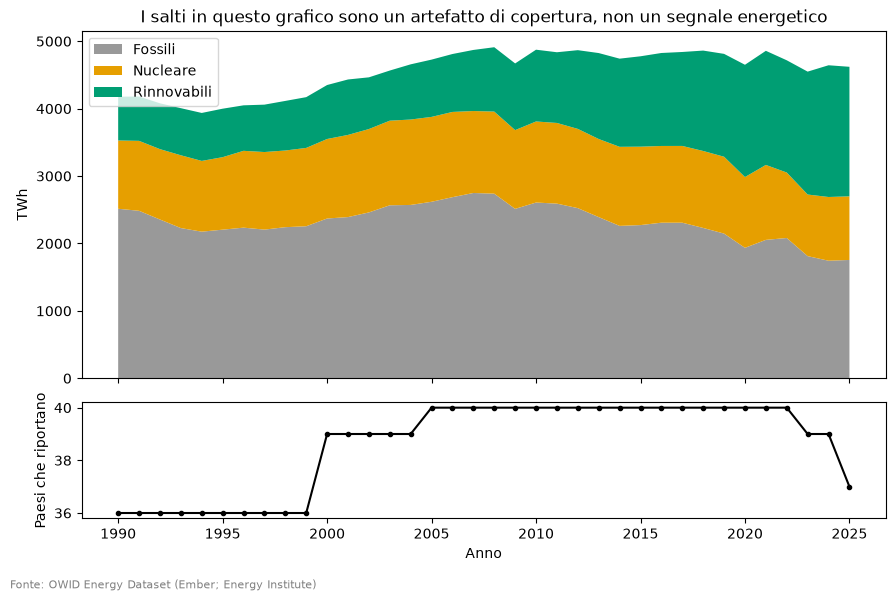

In [57]:
SOURCE_NOTE = "Fonte: OWID Energy Dataset (Ember; Energy Institute)"
PALETTE = {"fossile": "#999999", "nucleare": "#E69F00", "rinnovabili": "#009E73", "calo": "#D55E00"}

agg40 = (
    df_eu[df_eu["year"] >= 1990]
    .groupby("year")[["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]]
    .sum(min_count=1)
)
agg40["n_countries"] = (
    df_eu[df_eu["year"] >= 1990]
    .groupby("year")["electricity_generation"]
    .apply(lambda s: s.notna().sum())
)

# Due assi allineati (small multiples), non un dual axis sullo stesso plot:
# TWh e "numero di paesi" non condividono un'unità, sovrapporli sarebbe l'anti-pattern
# "dual axis" segnalato nel materiale del corso.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[3, 1])
ax1.stackplot(
    agg40.index,
    agg40["fossil_electricity"], agg40["nuclear_electricity"], agg40["renewables_electricity"],
    labels=["Fossili", "Nucleare", "Rinnovabili"],
    colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
)
ax1.set_title("I salti in questo grafico sono un artefatto di copertura, non un segnale energetico")
ax1.set_ylabel("TWh")
ax1.legend(loc="upper left")

ax2.plot(agg40.index, agg40["n_countries"], color="black", marker=".")
ax2.set_ylabel("Paesi che riportano")
ax2.set_xlabel("Anno")

fig.text(0.01, 0.01, SOURCE_NOTE, fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

Il pannello inferiore mostra la causa: il numero di paesi che contribuiscono alla somma passa da 36
(1990–99) a 39 (dal 2000) a 40 (dal ~2005), per poi scendere a 39 e 37 nel 2023–25 per il
right-censoring di Ucraina, Albania e Islanda (Cap. 3.3). Qui evitiamo deliberatamente un **dual axis**
(l'anti-pattern del corso: due unità diverse sullo stesso grafico "fanno vedere" una correlazione che
non è verificabile) usando invece due assi allineati sulla stessa x — il lettore vede il salto nella
serie e la sua causa senza dover fidarsi di una sovrapposizione arbitraria.

La correzione è restringersi a un **panel bilanciato**: paesi con serie completa 1990–2022 su tutte le
variabili chiave.

In [58]:
window = df_eu[(df_eu["year"] >= 1990) & (df_eu["year"] <= 2022)]

complete_countries = [
    country
    for country, grp in window.groupby("country")
    if grp.set_index("year").reindex(range(1990, 2023))[
        ["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]
    ].notna().all().all()
]
excluded = sorted(set(df_eu["country"].unique()) - set(complete_countries))
print(f"Paesi con serie completa 1990-2022: {len(complete_countries)} / {df_eu['country'].nunique()}")
print(f"Esclusi: {excluded}")

bal_all = window[window["country"].isin(complete_countries)]

# Quanto pesa l'esclusione? Confronto 2020, con e senza i due paesi esclusi più "estremi"
# (Svizzera: nucleare+idro quasi senza fossile; Islanda: 100% rinnovabile).
y = 2020
full40_y = df_eu[df_eu["year"] == y]
bal33_y = full40_y[full40_y["country"].isin(complete_countries)]

print("\n=== Quota sul totale europeo (media pesata per generazione, 2020) ===")
for label, d in [("40 paesi", full40_y), ("33 paesi (panel bilanciato)", bal33_y)]:
    tot = d["electricity_generation"].sum()
    shares = {k: d[f"{k}_electricity"].sum() / tot * 100 for k in ["fossil", "nuclear", "renewables"]}
    print(f"  {label}: {shares}")

print("\n=== Quota media per paese, non pesata (2020) ===")
for label, d in [("40 paesi", full40_y), ("33 paesi (panel bilanciato)", bal33_y)]:
    m = d[["fossil_share_elec", "nuclear_share_elec", "renewables_share_elec"]].mean()
    print(f"  {label}: {m.round(1).to_dict()}")

Paesi con serie completa 1990-2022: 33 / 40
Esclusi: ['Albania', 'Belarus', 'Bosnia and Herzegovina', 'Iceland', 'Moldova', 'Montenegro', 'Switzerland']

=== Quota sul totale europeo (media pesata per generazione, 2020) ===
  40 paesi: {'fossil': np.float64(41.610908681279476), 'nuclear': np.float64(22.580325781701056), 'renewables': np.float64(35.80876545692362)}
  33 paesi (panel bilanciato): {'fossil': np.float64(41.778459455718284), 'nuclear': np.float64(22.830169847444516), 'renewables': np.float64(35.39137064908388)}

=== Quota media per paese, non pesata (2020) ===
  40 paesi: {'fossil_share_elec': 43.0, 'nuclear_share_elec': 14.2, 'renewables_share_elec': 42.8}
  33 paesi (panel bilanciato): {'fossil_share_elec': 42.7, 'nuclear_share_elec': 16.1, 'renewables_share_elec': 41.2}


I 7 paesi esclusi (Albania, Bielorussia, Bosnia ed Erzegovina, Islanda, Moldova, Montenegro,
Svizzera) includono due casi estremi: la Svizzera (nucleare + idro, quasi zero fossile) e l'Islanda
(100% rinnovabile/geotermico). **L'esclusione non è innocua, ma il suo effetto dipende da come si
aggrega**: sulla quota europea pesata per generazione la differenza è minima (nucleare 22.6% → 22.8%,
rinnovabili 35.8% → 35.4%: la Svizzera e l'Islanda sono economie piccole, pesano poco sulla somma
assoluta). Sulla **media semplice per paese**, invece, l'effetto è più visibile (nucleare 14.2% → 16.1%,
rinnovabili 42.8% → 41.2%): qui ogni paese conta allo stesso modo, e togliere due profili estremi sposta
la media di alcuni punti. **Regola pratica**: per l'andamento aggregato europeo usare il panel bilanciato
con somme pesate (sotto); per confronti *tra* paesi non nascondere mai la selezione, ed eventualmente
permettere di reintrodurre Svizzera/Islanda come casi a parte.

### 4.2 Composizione vs confronto: stesso dato, due grafici

Lo stacked area risponde al task "di cosa è fatto il totale" (composizione). Ma la domanda del
progetto è un **confronto** tra tre andamenti — per quello l'encoding più accurato secondo Cleveland &
McGill è la **posizione su una scala comune** (una linea per fonte, stesso asse 0–100%), non lo
spessore di bande impilate su basi che si spostano. Li mettiamo affiancati per mostrare la differenza.

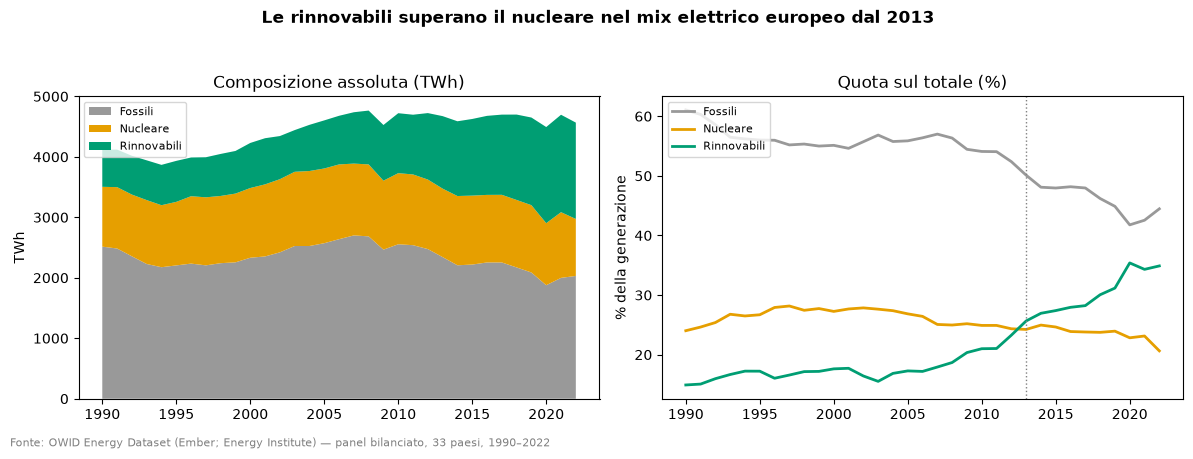

In [59]:
agg_bal = (
    bal_all.groupby("year")[["electricity_generation", "fossil_electricity", "nuclear_electricity", "renewables_electricity"]]
    .sum()
)
agg_bal_share = agg_bal.div(agg_bal["electricity_generation"], axis=0) * 100

crossover = agg_bal_share[agg_bal_share["renewables_electricity"] > agg_bal_share["nuclear_electricity"]].index.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].stackplot(
    agg_bal.index,
    agg_bal["fossil_electricity"], agg_bal["nuclear_electricity"], agg_bal["renewables_electricity"],
    labels=["Fossili", "Nucleare", "Rinnovabili"],
    colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
)
axes[0].set_title("Composizione assoluta (TWh)")
axes[0].set_ylabel("TWh")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].plot(agg_bal_share.index, agg_bal_share["fossil_electricity"], color=PALETTE["fossile"], label="Fossili", linewidth=2)
axes[1].plot(agg_bal_share.index, agg_bal_share["nuclear_electricity"], color=PALETTE["nucleare"], label="Nucleare", linewidth=2)
axes[1].plot(agg_bal_share.index, agg_bal_share["renewables_electricity"], color=PALETTE["rinnovabili"], label="Rinnovabili", linewidth=2)
axes[1].axvline(crossover, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Quota sul totale (%)")
axes[1].set_ylabel("% della generazione")
axes[1].legend(loc="upper left", fontsize=8)

fig.suptitle(f"Le rinnovabili superano il nucleare nel mix elettrico europeo dal {crossover}", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 33 paesi, 1990–2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

Il pannello di sinistra (composizione) mostra che il totale generato cresce e che i fossili restano il
blocco più grande in volume. Il pannello di destra (confronto) mostra il dato che lo stacked area
nasconde: le rinnovabili superano stabilmente il nucleare a partire dal 2013 (nel 1990 il nucleare
pesava il 24.0% contro il 14.9% delle rinnovabili; nel 2022 il rapporto è invertito, 20.6% contro
34.9%). I fossili scendono dal 61.1% al 44.5% ma restano maggioritari. Nessuna delle due letture è
"sbagliata": rispondono a due domande diverse, ed è per questo che nella dashboard **il tipo di
grafico dovrebbe seguire il task scelto dall'utente**, non essere fisso.

### 4.3 Quattro profili nazionali a confronto

La media europea nasconde traiettorie molto diverse. Scegliamo quattro paesi (nel panel bilanciato)
che rappresentano quattro strategie distinte, verificate sui dati 2022: Francia (nucleare stabile,
63%), Germania (transizione: fossile ancora dominante ma in calo, nucleare quasi azzerato,
rinnovabili in forte crescita), Polonia (fossile dominante, 79%, transizione appena iniziata),
Danimarca (rinnovabili leader, 81%, trainate dall'eolico). Small multiples con **assi condivisi**
(0–100%) per permettere il confronto diretto tra pannelli — l'antidoto del corso al dual axis quando
si vogliono confrontare più serie.

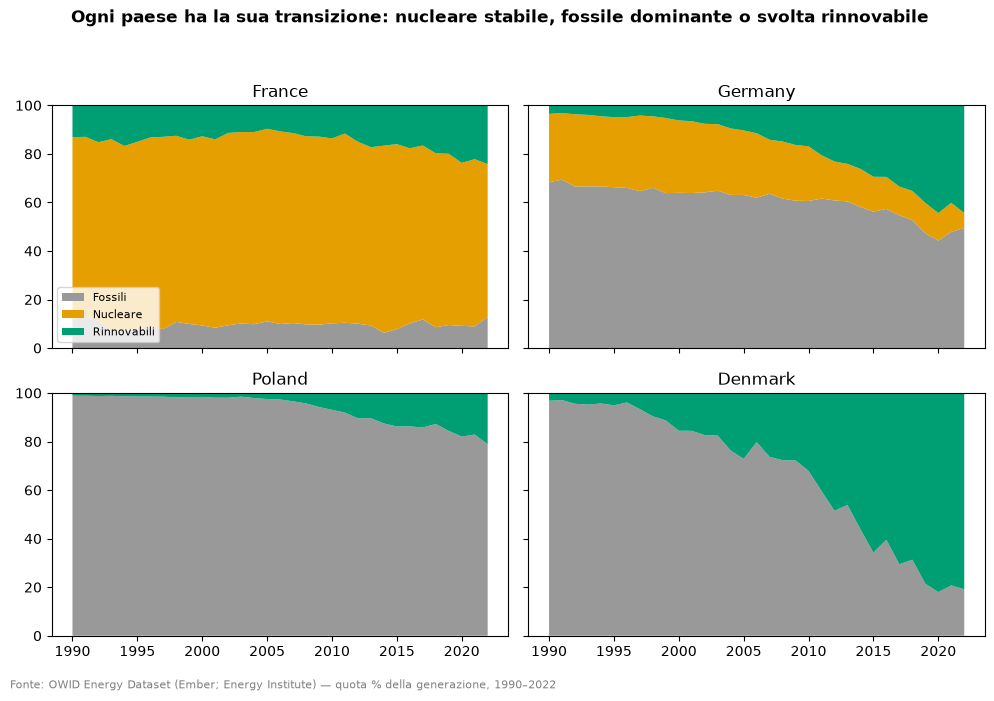

In [60]:
countries_profile = ["France", "Germany", "Poland", "Denmark"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, country in zip(axes.flat, countries_profile):
    d = bal_all[bal_all["country"] == country].sort_values("year")
    ax.stackplot(
        d["year"], d["fossil_share_elec"], d["nuclear_share_elec"], d["renewables_share_elec"],
        colors=[PALETTE["fossile"], PALETTE["nucleare"], PALETTE["rinnovabili"]],
        labels=["Fossili", "Nucleare", "Rinnovabili"],
    )
    ax.set_title(country)
    ax.set_ylim(0, 100)
axes[0, 0].legend(loc="lower left", fontsize=8)
fig.suptitle("Ogni paese ha la sua transizione: nucleare stabile, fossile dominante o svolta rinnovabile", fontweight="bold")
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — quota % della generazione, 1990–2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

La Germania è il caso più interessante per la dashboard: nel 1990 il mix era 68% fossile / 28%
nucleare / 3.5% rinnovabili, nel 2022 è 49.5% / 6.1% / 44.4% — il nucleare non è stato sostituito dalle
rinnovabili ma da un mix di rinnovabili in crescita e fossile ancora dominante (l'"Energiewende" è
un caso da segnalare esplicitamente in dashboard, perché il calo del nucleare tedesco spesso viene
letto — erroneamente — come prova che "le rinnovabili hanno sostituito il nucleare in Europa", mentre
è un pattern specifico di un singolo paese).

### 4.4 Chi ha trasformato di più il proprio mix?

Task di **confronto** puro: un valore per paese (variazione della quota rinnovabili 1990→2022).
Encoding scelto di conseguenza — bar orizzontale, ordinata per valore (non alfabeticamente), colore
diverging per isolare l'unico caso anomalo.

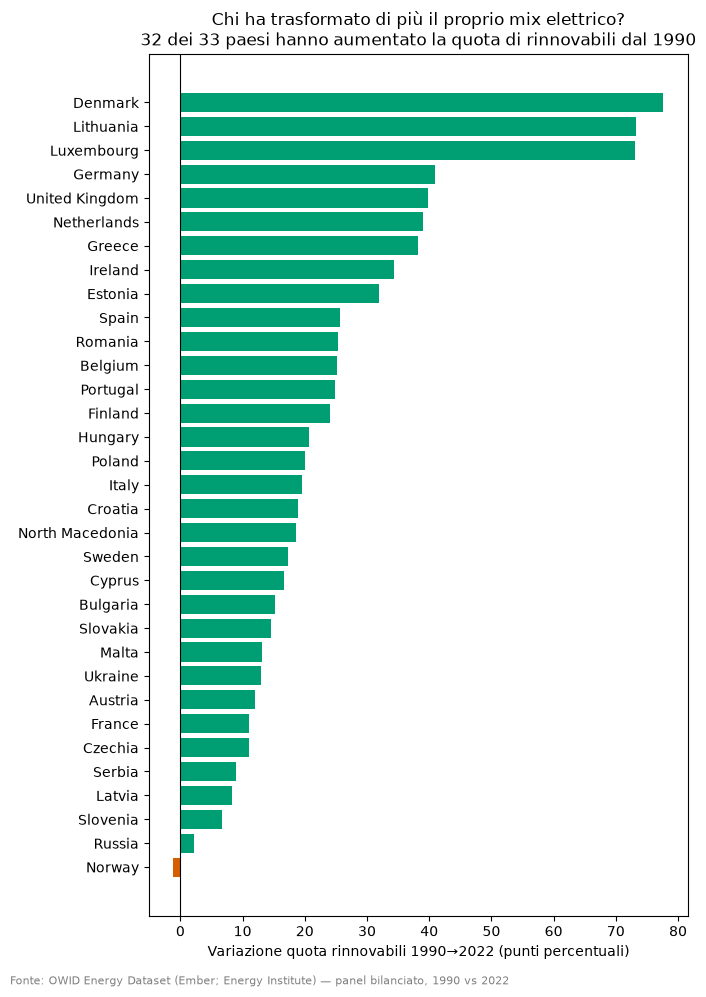

In [61]:
first_last = bal_all[bal_all["year"].isin([1990, 2022])].pivot(
    index="country", columns="year", values="renewables_share_elec"
)
delta = (first_last[2022] - first_last[1990]).sort_values()

colors = [PALETTE["calo"] if v < 0 else PALETTE["rinnovabili"] for v in delta]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(delta.index, delta.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Variazione quota rinnovabili 1990→2022 (punti percentuali)")
ax.set_title(
    f"Chi ha trasformato di più il proprio mix elettrico?\n"
    f"{(delta > 0).sum()} dei {len(delta)} paesi hanno aumentato la quota di rinnovabili dal 1990"
)
fig.text(0.01, 0.01, f"{SOURCE_NOTE} — panel bilanciato, 1990 vs 2022", fontsize=8, color="gray")
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

Danimarca, Lituania e Lussemburgo guidano la classifica (+73–78 punti). Il solo caso in calo è la
**Norvegia** (-1.1 punti): non è una regressione, è un **effetto soffitto** — era già al 99.8% nel
1990 (idroelettrico), quindi non ha margine di crescita. La Francia, invece, mostra una variazione
modesta (+11 punti) non perché sia rimasta ferma, ma perché nel 1990 partiva già da un mix a basse
emissioni grazie al nucleare: la metrica "variazione quota rinnovabili" penalizza chi ha scelto una
strada diversa (nucleare anziché rinnovabili) per lo stesso obiettivo di decarbonizzazione. Va
dichiarato in dashboard, altrimenti il grafico suggerisce implicitamente che la Francia abbia fatto
"poco", quando ha semplicemente seguito un altro percorso.

### 4.5 Sintesi per la dashboard

- **Dati**: panel bilanciato (33 paesi, 1990–2022) come default per confronti nel tempo; Svizzera e
  Islanda selezionabili a parte con avviso esplicito, non nascosti.
- **Tipo di grafico legato al task**, non fisso: stacked area per "composizione", linee su base 0–100%
  per "confronto" tra fonti, bar orizzontale ordinata per "chi ha fatto di più/meno".
- **Niente dual axis**: quando servono due grandezze non comparabili (es. TWh e numero di paesi), due
  pannelli allineati sulla stessa x, mai due assi Y sullo stesso plot.
- **Palette fissa e colorblind-safe** in tutta la dashboard (Okabe-Ito: grigio fossili, arancio
  nucleare, verde rinnovabili, rosso solo per evidenziare un'anomalia/calo).
- **Titoli-messaggio**, non etichette metodologiche, e fonte sempre visibile in calce a ogni grafico.
- **Metriche con contesto obbligatorio**: una classifica di "variazione quota rinnovabili" richiede una
  nota su chi partiva già decarbonizzato con un mix diverso (nucleare) — altrimenti la metrica
  penalizza implicitamente una strategia legittima.
- Selettore paesi con default suggerito: Francia, Germania, Polonia, Danimarca (quattro profili
  distinti), estendibile a qualunque paese del panel bilanciato.